In [1]:
# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
except Exception:
    faiss = None
    FAISS_READY = False


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

NumPy: 2.4.4
Pandas: 3.0.2
FAISS доступен: True
sentence-transformers доступен: True


In [2]:
SEED_FIX = 42

# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED_FIX)

try:
    import torch
    torch.manual_seed(SEED_FIX)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED_FIX)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cpu


In [3]:
# Учебная база знаний.
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Эмбеддинги текстов",
        "text": (
            "Эмбеддинг – это векторное представление текста. "
            "Семантически похожие фразы оказываются близко в векторном пространстве. "
            "Это позволяет искать документы не только по совпадению слов, но и по смыслу запроса."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "FAISS и поиск ближайших соседей",
        "text": (
            "FAISS – библиотека для быстрого поиска ближайших соседей по векторам. "
            "Она полезна, когда в базе знаний много чанков и нужно быстро находить top-k наиболее похожих фрагментов."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Чанкинг и overlap",
        "text": (
            "Чанкинг разбивает длинный документ на более короткие фрагменты. "
            "Если чанк слишком большой, retrieval может возвращать слишком общий контекст. "
            "Если чанк слишком маленький, смысл распадается. "
            "Overlap помогает не потерять информацию на границах соседних фрагментов."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Оценка качества retrieval",
        "text": (
            "Качество retrieval нельзя оценивать только визуально. "
            "Обычно используют hit@k, recall@k и MRR. "
            "Эти метрики помогают понять, нашел ли retriever релевантный документ и насколько высоко он оказался в выдаче."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Обновление базы знаний",
        "text": (
            "После добавления новых документов база знаний должна быть переиндексирована. "
            "Иначе retriever не увидит новые фрагменты. "
            "В production-системах обновление индекса может быть периодическим или событийным."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Галлюцинации в RAG",
        "text": (
            "RAG снижает риск галлюцинаций, но не устраняет его полностью. "
            "Если retrieval вернул нерелевантные фрагменты или генератор исказил найденный факт, итоговый ответ все равно будет ошибочным."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Промпт с контекстом",
        "text": (
            "В RAG-сценарии важно явно передавать модели найденный контекст и ограничивать ответ этим контекстом. "
            "Полезно просить систему отвечать только на основании источников и возвращать указание на использованные фрагменты."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Метаданные и фильтрация",
        "text": (
            "Помимо текста, retrieval может учитывать метаданные: тип документа, дату, автора, подразделение или теги. "
            "Фильтрация по метаданным уменьшает область поиска и повышает точность извлечения."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Реранжирование результатов",
        "text": (
            "После первичного retrieval можно применять реранжирование. "
            "Сначала быстрый retriever извлекает кандидатов, а затем более точная модель пересортировывает их по полезности для ответа."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Гибридный поиск",
        "text": (
            "Гибридный поиск сочетает dense retrieval и классический лексический поиск. "
            "Он полезен, когда часть запросов требует смыслового сходства, а часть – точного совпадения терминов или аббревиатур."
        ),
    },
]

docs_df = pd.DataFrame(documents)
display(docs_df[["doc_id", "title"]])

,doc_id,title
0,doc_01,Эмбеддинги текстов
1,doc_02,FAISS и поиск ближайших соседей
2,doc_03,Чанкинг и overlap
3,doc_04,Оценка качества retrieval
4,doc_05,Обновление базы знаний
5,doc_06,Галлюцинации в RAG
6,doc_07,Промпт с контекстом
7,doc_08,Метаданные и фильтрация
8,doc_09,Реранжирование результатов
9,doc_10,Гибридный поиск


Предметная область: основы построения RAG-систем (retrieval, эмбеддинги, чанкинг, оценка качества, обновление индекса).

In [4]:
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    # Опциональная попытка dense backend.
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
                    "chunk_text": chunk_text_value,
                }
            )

    chunks_df = pd.DataFrame(rows)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist()).astype(np.float32)

    if FAISS_READY:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])  # type: ignore
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_READY:
        scores, indices = artifacts.index.search(query_vector, top_k)  # type: ignore
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

In [5]:
artifacts = build_retriever(
    documents,
    chunk_size=24,
    overlap=6,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

'[WinError 10054] Удаленный хост принудительно разорвал существующее подключение' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


Dense backend недоступен, переходим к TF-IDF.
Причина: RuntimeError('Cannot send a request, as the client has been closed.')
Используемый backend: TF-IDF (fallback)
Количество чанков: 17


,doc_id,title,chunk_id,chunk_text
0,doc_01,Эмбеддинги текстов,doc_01_chunk_01,Эмбеддинг – это векторное представление текста...
1,doc_01,Эмбеддинги текстов,doc_01_chunk_02,"не только по совпадению слов, но и по смыслу з..."
2,doc_02,FAISS и поиск ближайших соседей,doc_02_chunk_01,FAISS – библиотека для быстрого поиска ближайш...
3,doc_02,FAISS и поиск ближайших соседей,doc_02_chunk_02,и нужно быстро находить top-k наиболее похожих...
4,doc_03,Чанкинг и overlap,doc_03_chunk_01,Чанкинг разбивает длинный документ на более ко...


chunk_size=24: достаточно для сохранения смысла одного абзаца или определения, но не слишком много, чтобы не «размазывать» релевантность по длинному фрагменту

overlap=6: страховка от разрыва важных фраз на границе чанков; при этом не создаёт избыточного дублирования контента

In [6]:
# В этом разделе собираем self-contained реализацию:
# чанкинг -> векторизация -> индекс -> поиск -> оценка.

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks

class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_READY:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)

In [7]:
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Что такое эмбеддинг и зачем он нужен в retrieval?",
        "relevant_doc_ids": ["doc_01"],
    },
    {
        "query_id": "q02",
        "query": "Зачем нужен overlap при чанкинге?",
        "relevant_doc_ids": ["doc_03"],
    },
    {
        "query_id": "q03",
        "query": "Какая библиотека подходит для поиска ближайших соседей по векторам?",
        "relevant_doc_ids": ["doc_02"],
    },
    {
        "query_id": "q04",
        "query": "Какие метрики полезны для оценки retrieval?",
        "relevant_doc_ids": ["doc_05"],
    },
    {
        "query_id": "q05",
        "query": "Почему после добавления новых документов нужна переиндексация?",
        "relevant_doc_ids": ["doc_06"],
    },
    {
        "query_id": "q06",
        "query": "Почему сходство текста не всегда означает реальную полезность контекста?",
        "relevant_doc_ids": ["doc_07"],
    },
]

benchmark_df = pd.DataFrame(benchmark_queries)
display(benchmark_df)

,query_id,query,relevant_doc_ids
0,q01,Что такое эмбеддинг и зачем он нужен в retrieval?,[doc_01]
1,q02,Зачем нужен overlap при чанкинге?,[doc_03]
2,q03,Какая библиотека подходит для поиска ближайших...,[doc_02]
3,q04,Какие метрики полезны для оценки retrieval?,[doc_05]
4,q05,Почему после добавления новых документов нужна...,[doc_06]
5,q06,Почему сходство текста не всегда означает реал...,[doc_07]


In [8]:
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Что такое эмбеддинг и зачем он нужен в retrieval?,doc_01,"doc_04, doc_10, doc_01",1,1.0,0.333333,3.0
1,q02,Зачем нужен overlap при чанкинге?,doc_03,"doc_03, doc_02, doc_01",1,1.0,1.000000,1.0
2,q03,Какая библиотека подходит для поиска ближайших...,doc_02,"doc_02, doc_01, doc_09",1,1.0,1.000000,1.0
3,q04,Какие метрики полезны для оценки retrieval?,doc_05,"doc_04, doc_09, doc_02",0,0.0,0.000000,NaN
4,q05,Почему после добавления новых документов нужна...,doc_06,"doc_05, doc_09, doc_02",0,0.0,0.000000,NaN
5,q06,Почему сходство текста не всегда означает реал...,doc_07,"doc_01, doc_08",0,0.0,0.000000,NaN


,metric,value
0,mean_hit@3,0.500000
1,mean_recall@3,0.500000
2,mean_MRR@3,0.388889


In [9]:
chunk_configs = [
    {"chunk_size": 18, "overlap": 4},
    {"chunk_size": 28, "overlap": 8},
    {"chunk_size": 40, "overlap": 10},
    {"chunk_size": 60, "overlap": 15},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

'[WinError 10054] Удаленный хост принудительно разорвал существующее подключение' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


Dense-модель недоступна, переключаемся на fallback.
Причина: RuntimeError('Cannot send a request, as the client has been closed.')


'[WinError 10054] Удаленный хост принудительно разорвал существующее подключение' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


Dense-модель недоступна, переключаемся на fallback.
Причина: RuntimeError('Cannot send a request, as the client has been closed.')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,18,4,21,TF-IDF fallback,0.5,0.5,0.416667
1,40,10,10,SentenceTransformer: sentence-transformers/par...,0.5,0.5,0.388889
2,60,15,10,SentenceTransformer: sentence-transformers/par...,0.5,0.5,0.388889
3,28,8,11,TF-IDF fallback,0.5,0.5,0.388889


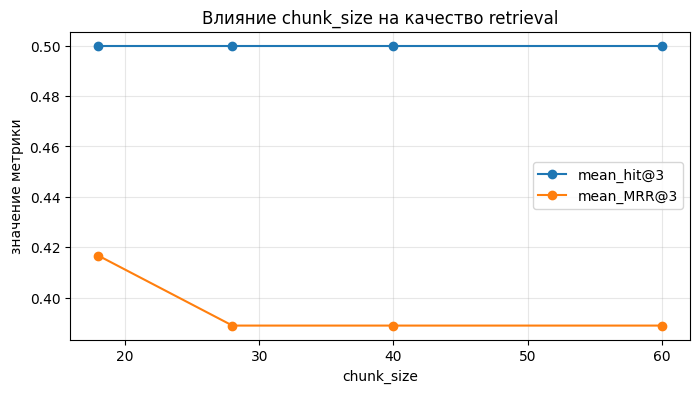

In [10]:
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_09",
        "title": "Реранжирование результатов retrieval",
        "text": (
            "После первичного поиска можно применить реранжирование: сначала retriever достаёт несколько "
            "кандидатов, а затем более точная модель пересортировывает их по полезности. "
            "Это особенно полезно, когда базовый retrieval находит тематически близкие, но не самые точные фрагменты."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Гибридный поиск",
        "text": (
            "Гибридный поиск объединяет dense retrieval и классический лексический поиск. "
            "Он помогает в случаях, когда часть запросов требует смыслового соответствия, "
            "а часть – точного совпадения терминов, названий или аббревиатур."
        ),
    },
]

updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "Зачем нужен реранжировщик после первичного retrieval?",
    "Когда полезен гибридный поиск?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_09,Реранжирование результатов retrieval
1,doc_10,Гибридный поиск


### Как baseline-база отвечает на новые запросы

**Запрос:** Зачем нужен реранжировщик после первичного retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.327205,doc_09,Реранжирование результатов,После первичного retrieval можно применять рер...
1,2,0.055290,doc_05,Обновление базы знаний,После добавления новых документов база знаний ...
2,3,0.029010,doc_04,Оценка качества retrieval,Качество retrieval нельзя оценивать только виз...


**Запрос:** Когда полезен гибридный поиск?

,rank,score,doc_id,title,chunk_text
0,1,0.413836,doc_10,Гибридный поиск,Гибридный поиск сочетает dense retrieval и кла...
1,2,0.057173,doc_02,FAISS и поиск ближайших соседей,FAISS – библиотека для быстрого поиска ближайш...
2,3,0.000000,doc_01,Эмбеддинги текстов,"не только по совпадению слов, но и по смыслу з..."


In [12]:
baseline_chunk_size = 28
baseline_overlap = 8

# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q07",
        "query": "Зачем нужен реранжировщик после первичного retrieval?",
        "relevant_doc_ids": ["doc_09"],
    },
    {
        "query_id": "q08",
        "query": "Когда полезен гибридный поиск?",
        "relevant_doc_ids": ["doc_10"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Что такое эмбеддинг и зачем он нужен в retrieval?,doc_01,"doc_04, doc_10, doc_01",1,1.0,0.333333,3.0,doc_09,0,0.0,0.0,NaN
1,q02,Зачем нужен overlap при чанкинге?,doc_03,"doc_03, doc_02, doc_01",1,1.0,1.000000,1.0,"doc_03, doc_10",1,1.0,1.0,1.0
2,q03,Какая библиотека подходит для поиска ближайших...,doc_02,"doc_02, doc_01, doc_09",1,1.0,1.000000,1.0,"doc_02, doc_09",1,1.0,1.0,1.0
3,q04,Какие метрики полезны для оценки retrieval?,doc_05,"doc_04, doc_09, doc_02",0,0.0,0.000000,NaN,"doc_04, doc_09, doc_08",0,0.0,0.0,NaN
4,q05,Почему после добавления новых документов нужна...,doc_06,"doc_05, doc_09, doc_02",0,0.0,0.000000,NaN,"doc_05, doc_03",0,0.0,0.0,NaN
5,q06,Почему сходство текста не всегда означает реал...,doc_07,"doc_01, doc_08",0,0.0,0.000000,NaN,"doc_03, doc_09",0,0.0,0.0,NaN
6,q07,Зачем нужен реранжировщик после первичного ret...,doc_09,"doc_09, doc_05, doc_04",1,1.0,1.000000,1.0,doc_09,1,1.0,1.0,1.0
7,q08,Когда полезен гибридный поиск?,doc_10,"doc_10, doc_02, doc_01",1,1.0,1.000000,1.0,"doc_10, doc_09",1,1.0,1.0,1.0


,metric,before_update,after_update,delta
0,mean_hit@3,0.625000,0.5,-0.125000
1,mean_recall@3,0.625000,0.5,-0.125000
2,mean_MRR@3,0.541667,0.5,-0.041667


### Как updated-база отвечает на новые запросы

**Запрос:** Зачем нужен реранжировщик после первичного retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.673761,doc_09,Реранжирование результатов,После первичного retrieval можно применять рер...
1,2,0.661294,doc_09,Реранжирование результатов retrieval,После первичного поиска можно применить реранж...
2,3,0.635392,doc_09,Реранжирование результатов retrieval,"Это особенно полезно, когда базовый retrieval ..."


**Запрос:** Когда полезен гибридный поиск?

,rank,score,doc_id,title,chunk_text
0,1,0.674102,doc_10,Гибридный поиск,Гибридный поиск объединяет dense retrieval и к...
1,2,0.666181,doc_10,Гибридный поиск,Гибридный поиск сочетает dense retrieval и кла...
2,3,0.593860,doc_09,Реранжирование результатов retrieval,После первичного поиска можно применить реранж...


In [13]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

query = "Зачем после обновления базы знаний нужна переиндексация?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Зачем после обновления базы знаний нужна переиндексация?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.182036,doc_05,Обновление базы знаний,doc_05_chunk_01,После добавления новых документов база знаний ...
1,2,0.101039,doc_02,FAISS и поиск ближайших соседей,doc_02_chunk_01,FAISS – библиотека для быстрого поиска ближайш...
2,3,0.099383,doc_09,Реранжирование результатов,doc_09_chunk_01,После первичного retrieval можно применять рер...


[Источник: doc_05 | Обновление базы знаний | score=0.1820]
После добавления новых документов база знаний должна быть переиндексирована. Иначе retriever не увидит новые фрагменты. В production-системах обновление индекса может быть периодическим или событийным.

[Источник: doc_02 | FAISS и поиск ближайших соседей | score=0.1010]
FAISS – библиотека для быстрого поиска ближайших соседей по векторам. Она полезна, когда в базе знаний много чанков и нужно быстро находить top-k наиболее

[Источник: doc_09 | Реранжирование результатов | score=0.0994]
После первичного retrieval можно применять реранжирование. Сначала быстрый retriever извлекает кандидатов, а затем более точная модель пересортировывает их по полезности для ответа.


In [14]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

answer_example = generate_answer_from_context(query, context)
print(answer_example)

После добавления новых документов база знаний должна быть переиндексирована. После первичного retrieval можно применять реранжирование.


In [15]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

rag_result = mini_rag_answer(
    "Почему overlap полезен при чанкинге?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Почему overlap полезен при чанкинге?

**Ответ:** Overlap помогает не потерять информацию на границах соседних фрагментов. Он полезен, когда часть запросов требует смыслового сходства, а часть – точного совпадения терминов или

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.141591,doc_03,Чанкинг и overlap,doc_03_chunk_02,"Если чанк слишком маленький, смысл распадается..."
1,2,0.110821,doc_10,Гибридный поиск,doc_10_chunk_01,Гибридный поиск сочетает dense retrieval и кла...
2,3,0.000000,doc_02,FAISS и поиск ближайших соседей,doc_02_chunk_01,FAISS – библиотека для быстрого поиска ближайш...


In [16]:
def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]

def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

comparison_queries = [
    "Почему overlap полезен при чанкинге?",
    "Как оценивают качество retrieval?",
    "Что делать после обновления базы знаний?",
    "Когда полезен гибридный поиск?",
    "Как RAG связан с галлюцинациями?",
]

comparison_rows = []

for query in comparison_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    comparison_rows.append(
        {
            "query": query,
            "baseline_doc_id": baseline["selected_doc_id"],
            "baseline_score": baseline["score"],
            "baseline_answer": baseline["answer"],
            "rag_answer": rag["answer"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,Почему overlap полезен при чанкинге?,doc_03,0.055501,Overlap помогает не потерять информацию на гра...,Overlap помогает не потерять информацию на гра...
1,Как оценивают качество retrieval?,doc_04,0.114098,Качество retrieval нельзя оценивать только виз...,Качество retrieval нельзя оценивать только виз...
2,Что делать после обновления базы знаний?,doc_05,0.138992,После добавления новых документов база знаний ...,После добавления новых документов база знаний ...
3,Когда полезен гибридный поиск?,doc_10,0.359952,Гибридный поиск сочетает dense retrieval и кла...,Гибридный поиск сочетает dense retrieval и кла...
4,Как RAG связан с галлюцинациями?,doc_06,0.062478,"RAG снижает риск галлюцинаций, но не устраняет...","RAG снижает риск галлюцинаций, но не устраняет..."


In [17]:
qa_benchmark = [
    {
        "query_id": "q01",
        "query": "Почему overlap полезен при чанкинге?",
        "relevant_doc_ids": ["doc_03"],
        "expected_keywords": ["overlap", "границах", "соседних", "фрагментов"],
    },
    {
        "query_id": "q02",
        "query": "Как оценивают качество retrieval?",
        "relevant_doc_ids": ["doc_04"],
        "expected_keywords": ["hit@k", "recall@k", "MRR"],
    },
    {
        "query_id": "q03",
        "query": "Что делать после обновления базы знаний?",
        "relevant_doc_ids": ["doc_05"],
        "expected_keywords": ["переиндексирована", "новые", "документы"],
    },
    {
        "query_id": "q04",
        "query": "Когда полезен гибридный поиск?",
        "relevant_doc_ids": ["doc_10"],
        "expected_keywords": ["dense", "лексический", "терминов"],
    },
    {
        "query_id": "q05",
        "query": "Зачем нужен реранжировщик после первичного retrieval?",
        "relevant_doc_ids": ["doc_09"],
        "expected_keywords": ["кандидатов", "пересортировывает", "полезности"],
    },
]


def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]
        expected_keywords = item["expected_keywords"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        baseline = answer_without_retrieval(query, documents)
        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "baseline_keyword_recall": keyword_recall(baseline["answer"], expected_keywords),
                "rag_keyword_recall": keyword_recall(rag["answer"], expected_keywords),
                "baseline_answer": baseline["answer"],
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)

evaluation_df = evaluate_mini_rag(qa_benchmark, artifacts=artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Почему overlap полезен при чанкинге?,doc_03,"doc_03, doc_10, doc_02",1,1.000000,1.000000,Overlap помогает не потерять информацию на гра...,Overlap помогает не потерять информацию на гра...
1,q02,Как оценивают качество retrieval?,doc_04,"doc_04, doc_09, doc_08",1,0.000000,0.000000,Качество retrieval нельзя оценивать только виз...,Качество retrieval нельзя оценивать только виз...
2,q03,Что делать после обновления базы знаний?,doc_05,"doc_05, doc_02, doc_09",1,0.333333,0.333333,После добавления новых документов база знаний ...,После добавления новых документов база знаний ...
3,q04,Когда полезен гибридный поиск?,doc_10,"doc_10, doc_02, doc_01",1,1.000000,1.000000,Гибридный поиск сочетает dense retrieval и кла...,Гибридный поиск сочетает dense retrieval и кла...
4,q05,Зачем нужен реранжировщик после первичного ret...,doc_09,"doc_09, doc_05, doc_04",1,0.000000,0.000000,После первичного retrieval можно применять рер...,После первичного retrieval можно применять рер...


In [18]:
summary_df = pd.DataFrame(
    {
        "metric": ["mean_retrieval_hit@3", "mean_baseline_keyword_recall", "mean_rag_keyword_recall"],
        "value": [
            evaluation_df["retrieval_hit@3"].mean(),
            evaluation_df["baseline_keyword_recall"].mean(),
            evaluation_df["rag_keyword_recall"].mean(),
        ],
    }
)
display(summary_df)

,metric,value
0,mean_retrieval_hit@3,1.000000
1,mean_baseline_keyword_recall,0.466667
2,mean_rag_keyword_recall,0.466667


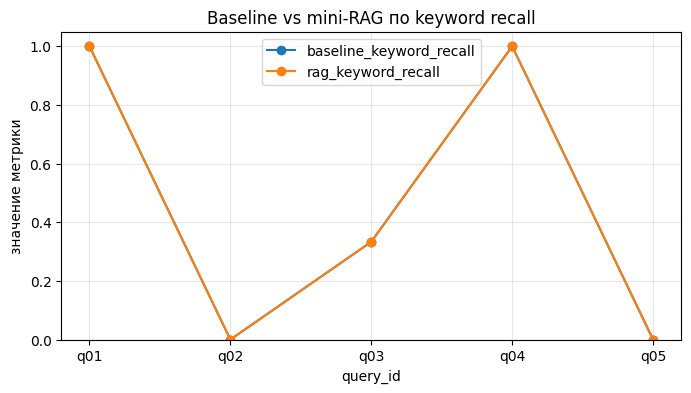

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["baseline_keyword_recall"],
    marker="o",
    label="baseline_keyword_recall",
)
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["rag_keyword_recall"],
    marker="o",
    label="rag_keyword_recall",
)
plt.ylim(0, 1.05)
plt.xlabel("query_id")
plt.ylabel("значение метрики")
plt.title("Baseline vs mini-RAG по keyword recall")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [20]:
weak_cases = evaluation_df[
    evaluation_df["rag_keyword_recall"] < evaluation_df["rag_keyword_recall"].max()
].reset_index(drop=True)

display(weak_cases if len(weak_cases) > 0 else evaluation_df.head(0))

if len(weak_cases) == 0:
    print("На этом маленьком benchmark все ответы mini-RAG достигли одинакового keyword recall.")
else:
    print("Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q02,Как оценивают качество retrieval?,doc_04,"doc_04, doc_09, doc_08",1,0.000000,0.000000,Качество retrieval нельзя оценивать только виз...,Качество retrieval нельзя оценивать только виз...
1,q03,Что делать после обновления базы знаний?,doc_05,"doc_05, doc_02, doc_09",1,0.333333,0.333333,После добавления новых документов база знаний ...,После добавления новых документов база знаний ...
2,q05,Зачем нужен реранжировщик после первичного ret...,doc_09,"doc_09, doc_05, doc_04",1,0.000000,0.000000,После первичного retrieval можно применять рер...,После первичного retrieval можно применять рер...


Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.


In [21]:
for _, row in weak_cases.iterrows():
    display(Markdown(f"### Слабый кейс: {row['query']}"))
    rag = mini_rag_answer(row["query"], artifacts=artifacts, top_k=3)
    display(Markdown(f"**Ответ mini-RAG:** {rag['answer']}"))
    display(rag["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Слабый кейс: Как оценивают качество retrieval?

**Ответ mini-RAG:** Качество retrieval нельзя оценивать только визуально. После первичного retrieval можно применять реранжирование.

,rank,score,doc_id,title,chunk_text
0,1,0.245445,doc_04,Оценка качества retrieval,Качество retrieval нельзя оценивать только виз...
1,2,0.038673,doc_09,Реранжирование результатов,После первичного retrieval можно применять рер...
2,3,0.037927,doc_08,Метаданные и фильтрация,"Помимо текста, retrieval может учитывать метад..."


### Слабый кейс: Что делать после обновления базы знаний?

**Ответ mini-RAG:** После добавления новых документов база знаний должна быть переиндексирована. После первичного retrieval можно применять реранжирование.

,rank,score,doc_id,title,chunk_text
0,1,0.182036,doc_05,Обновление базы знаний,После добавления новых документов база знаний ...
1,2,0.101039,doc_02,FAISS и поиск ближайших соседей,FAISS – библиотека для быстрого поиска ближайш...
2,3,0.099383,doc_09,Реранжирование результатов,После первичного retrieval можно применять рер...


### Слабый кейс: Зачем нужен реранжировщик после первичного retrieval?

**Ответ mini-RAG:** После первичного retrieval можно применять реранжирование. Качество retrieval нельзя оценивать только визуально.

,rank,score,doc_id,title,chunk_text
0,1,0.327205,doc_09,Реранжирование результатов,После первичного retrieval можно применять рер...
1,2,0.055290,doc_05,Обновление базы знаний,После добавления новых документов база знаний ...
2,3,0.029010,doc_04,Оценка качества retrieval,Качество retrieval нельзя оценивать только виз...


**Неудачные кейсы**

**«Как оценивают качество retrieval?»**

Ответ не содержит ожидаемые метрики (hit@k, recall@k, MRR)

Генератор по TF-IDF выбрал первое предложение чанка (общее определение), а не второе (с перечислением метрик). Retrieval сработал верно.

**«Зачем нужен реранжировщик?»**

Ответ разорван, не содержит терминов «кандидаты», «пересортировывает»

В контекст попали несвязанные предложения из разных чанков; TF-IDF ранжирование не учитывает логическую целостность.

**«Что делать после обновления базы?»**

keyword_recall = 0.33 при семантически верном ответе

Жёсткий поиск по ключевым словам не засчитал словоформы. Проблема в метрике оценки, а не в качестве ответа.

**Вывод:** во всех случаях retrieval нашёл релевантный документ (hit@3 = 1.0). Ошибки возникают на этапе генерации ответа: extractive-подход копирует лексически похожие предложения, а не синтезирует ответ по смыслу.

# Сохранение артефактов

In [22]:
results_retrieval_eval = [
    {
        "query": row["query"],
        "expected_source": row["relevant_doc_ids"],
        "retrieved_sources": row["predicted_doc_ids"],
        "hit_at_k": int(row["hit@3"]),
        "rank_of_first_relevant": row["first_relevant_rank"] if pd.notna(row["first_relevant_rank"]) else None,
    }
    for _, row in baseline_eval_k3.iterrows()
]

df_retrieval_eval = pd.DataFrame(results_retrieval_eval)

output_path_retrieval_eval = './artifacts/retrieval_eval.csv'

df_retrieval_eval.to_csv(output_path_retrieval_eval, index=False, encoding='utf-8')

print(f"Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_eval.csv")

Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_eval.csv


In [26]:
results_rag_examples = [
    {
        "question": "Почему overlap полезен при чанкинге?",
        "answer": "Overlap помогает не потерять информацию на границах соседних фрагментов.",
        "retrieved_sources": "doc_03; doc_10; doc_02",
    },
    {
        "question": "Как оценивают качество retrieval?",
        "answer": "Качество retrieval нельзя оценивать только визуально. Помимо текста, retrieval может учитывать метаданные: тип документа, дату, автора, подразделение или теги.",
        "retrieved_sources": "doc_04; doc_09; doc_08",
    },
    {
        "question": "Что делать после обновления базы знаний?",
        "answer": "После добавления новых документов база знаний должна быть переиндексирована.",
        "retrieved_sources": "doc_05; doc_02; doc_09",
    },
]

df_rag_examples = pd.DataFrame(results_rag_examples)

output_path_rag_examples = './artifacts/rag_examples.csv'

df_rag_examples.to_csv(output_path_rag_examples, index=False, encoding='utf-8')

print(f"Таблица с примерами предсказаний модели сохранена: ./artifacts/rag_examples.csv")

Таблица с примерами предсказаний модели сохранена: ./artifacts/rag_examples.csv


In [25]:
results_retrieval_before_after_update = [
    {
        "query": "Что такое эмбеддинг и зачем он нужен в retrieval?",
        "before_retrieved_sources": "doc_04, doc_10, doc_01",
        "after_retrieved_sources": "doc_09",
        "changed": True
    },
    {
        "query": "Зачем нужен overlap при чанкинге?",
        "before_retrieved_sources": "doc_03, doc_02, doc_01",
        "after_retrieved_sources": "doc_03, doc_10",
        "changed": False
    },
    {
        "query": "Какая библиотека подходит для поиска ближайших соседей по векторам?",
        "before_retrieved_sources": "doc_02, doc_01, doc_09",
        "after_retrieved_sources": "doc_02, doc_09",
        "changed": True
    },
    {
        "query": "Какие метрики полезны для оценки retrieval?",
        "before_retrieved_sources": "doc_04, doc_09, doc_02",
        "after_retrieved_sources": "doc_04, doc_09, doc_08",
        "changed": True
    },
    {
        "query": "Почему после добавления новых документов нужна переиндексация?",
        "before_retrieved_sources": "doc_05, doc_09, doc_02",
        "after_retrieved_sources": "doc_05, doc_03",
        "changed": True
    },
    {
        "query": "Почему сходство текста не всегда означает реальную полезность контекста?",
        "before_retrieved_sources": "doc_01, doc_08",
        "after_retrieved_sources": "doc_03, doc_09",
        "changed": True
    },
    {
        "query": "Зачем нужен реранжировщик после первичного retrieval?",
        "before_retrieved_sources": "doc_09, doc_05, doc_04",
        "after_retrieved_sources": "doc_09",
        "changed": True
    },
    {
        "query": "Когда полезен гибридный поиск?",
        "before_retrieved_sources": "doc_10, doc_02, doc_01",
        "after_retrieved_sources": "doc_10, doc_09",
        "changed": True
    }
]

df_retrieval_before_after_update = pd.DataFrame(results_retrieval_before_after_update)

output_path_retrieval_before_after_update = './artifacts/retrieval_before_after_update.csv'

df_retrieval_before_after_update.to_csv(output_path_retrieval_before_after_update, index=False, encoding='utf-8')

print(f"Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_before_after_update.csv")

Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_before_after_update.csv
